In [1]:
from matplotlib import pyplot as plt
from matplotlib import colors
import numpy as np
from matplotlib.patches import Path, PathPatch
import pandas as pd
from shapely.geometry import Point, shape, Polygon
from shapely.ops import unary_union, cascaded_union
from geopandas.tools import sjoin
import geopandas as gpd
from netCDF4 import Dataset
from cartopy import crs as ccrs
from cartopy.io.shapereader import Reader
from sklearn.metrics import mean_squared_error
import scipy.stats as st
from sklearn.linear_model import LinearRegression
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import LAKES
import geopandas as gpd
from matplotlib.colors import BoundaryNorm, ListedColormap
import numpy as np
from netCDF4 import Dataset
from matplotlib.offsetbox import AnchoredText
from matplotlib.colors import TwoSlopeNorm

C:\Users\x12la\AppData\Local\Temp\ipykernel_11480\3072201630.py:8: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  from geopandas.tools import sjoin


In [2]:
# Get lat/lon from LADCO grid and find corners of domain
# this is to be used for map extents
grid='C:/Users/x12la/Desktop/latlon_ChicagoLADCO_d03.nc'
# Silly note- DO2 file uses capital LAT LON and d03 uses lowercase 
cmaq_lon,cmaq_lat=np.array(Dataset(grid)['lon']),np.array(Dataset(grid)['lat'])
llat,ulat,llon,ulon=cmaq_lat.min(), cmaq_lat.max(), cmaq_lon.min(), cmaq_lon.max()
print(llat,ulat,llon,ulon)

#CMAP 7 counties surrounding Chicago/Cook County
cmap_cty = gpd.read_file('C:/Users/x12la/Desktop/Scripts/CMAP_cty.shp')
cmap_cty = cmap_cty.to_crs('EPSG:4326')

40.210953 44.045914 -90.07886 -84.51282


In [3]:
# EPA DEFUALT 
gas_base = gpd.read_file(r"emis_mole_onroad_gas_2023_average_baseline.shp").to_crs("EPSG:4326")
diesel_base = gpd.read_file(r"emis_mole_onroad_diesel_2023_average_baseline.shp").to_crs("EPSG:4326")

common_cols = [c for c in gas_base.columns if c in diesel_base.columns]
cols_to_sum = [
    c for c in common_cols
    if c not in ["geometry", "lat", "lon", "lat_m", "lon_m"]
    and np.issubdtype(gas_base[c].dtype, np.number)
]

onroad_total_base = gas_base.copy()
onroad_total_base[cols_to_sum] = (
    gas_base[cols_to_sum].fillna(0).to_numpy()
    + diesel_base[cols_to_sum].fillna(0).to_numpy()
)

onroad_total_base_cmap = gpd.clip(onroad_total_base, cmap_cty)

#  Onr-road mod
gas_HDVSpatial = gpd.read_file(r"../2022v1_Baseline/emis_mole_onroad_gas_2023_average_HDVSpatial.shp").to_crs("EPSG:4326")
diesel_HDVSpatial = gpd.read_file(r"../2022v1_Baseline/emis_mole_onroad_diesel_2023_average_HPVSpatial.shp").to_crs("EPSG:4326")

common_cols = [c for c in gas_HDVSpatial.columns if c in diesel_HDVSpatial.columns]
cols_to_sum = [
    c for c in common_cols
    if c not in ["geometry", "lat", "lon", "lat_m", "lon_m"]
    and np.issubdtype(gas_HDVSpatial[c].dtype, np.number)
]

onroad_total_HDVSpatial = gas_HDVSpatial.copy()
onroad_total_HDVSpatial[cols_to_sum] = (
    gas_HDVSpatial[cols_to_sum].fillna(0).to_numpy()
    + diesel_HDVSpatial[cols_to_sum].fillna(0).to_numpy()
)
onroad_total_HDVSpatial_cmap = gpd.clip(onroad_total_HDVSpatial, cmap_cty)

#  LOCUS Idling — ALL VEHICLES
gas_LOCUSIdling = gpd.read_file(
    r"emis_mole_onroad_gas_2023_LOCUSIdling_annualavg.shp"
).to_crs("EPSG:4326")

diesel_LOCUSIdling = gpd.read_file(
    r"emis_mole_onroad_diesel_2023_LOCUSIdling_annualavg.shp"
).to_crs("EPSG:4326")

common_cols = [c for c in gas_LOCUSIdling.columns if c in diesel_LOCUSIdling.columns]
cols_to_sum = [
    c for c in common_cols
    if c not in ["geometry", "lat", "lon", "lat_m", "lon_m"]
    and np.issubdtype(gas_LOCUSIdling[c].dtype, np.number)
]

onroad_total_LOCUSIdling = gas_LOCUSIdling.copy()
onroad_total_LOCUSIdling[cols_to_sum] = (
    gas_LOCUSIdling[cols_to_sum].fillna(0).to_numpy()
    + diesel_LOCUSIdling[cols_to_sum].fillna(0).to_numpy()
)

onroad_total_LOCUSIdling_cmap = gpd.clip(onroad_total_LOCUSIdling, cmap_cty)


# Idling and on-road modification 
gas_LOCUSIdlingHDVSpatial = gpd.read_file(
    r"emis_mole_onroad_gas_2023_LOCUSIdlingHDVSpatial_annualavg.shp"
).to_crs("EPSG:4326")

diesel_LOCUSIdlingHDVSpatial = gpd.read_file(
    r"emis_mole_onroad_diesel_2023_LOCUSIdlingHDVSpatial_annualavg.shp"
).to_crs("EPSG:4326")

common_cols = [c for c in gas_LOCUSIdlingHDVSpatial.columns if c in diesel_LOCUSIdlingHDVSpatial.columns]
cols_to_sum = [
    c for c in common_cols
    if c not in ["geometry", "lat", "lon", "lat_m", "lon_m"]
    and np.issubdtype(gas_LOCUSIdlingHDVSpatial[c].dtype, np.number)
]

onroad_total_LOCUSIdlingHDVSpatial = gas_LOCUSIdlingHDVSpatial.copy()
onroad_total_LOCUSIdlingHDVSpatial[cols_to_sum] = (gas_LOCUSIdlingHDVSpatial[cols_to_sum].fillna(0).to_numpy()
    + diesel_LOCUSIdlingHDVSpatial[cols_to_sum].fillna(0).to_numpy())

onroad_total_LOCUSIdlingHDVSpatial_cmap = gpd.clip(onroad_total_LOCUSIdlingHDVSpatial, cmap_cty)

In [14]:
#primary roads
primary_roads = gpd.read_file('C:/Users/x12la/Desktop/Scripts/tl_2016_us_primaryroads.shp')
primary_roads = primary_roads.to_crs('EPSG:4326')

cmap_roads = gpd.clip(primary_roads, cmap_cty)
cmap_roads = cmap_roads[cmap_roads.geometry.geom_type.isin(["LineString", "MultiLineString"])].copy()

In [8]:
def calc_nox_peryear(gdf, cell_km=1.33):
    """
    Calculate annual NOx emissions in tons/km2/year.
    NO and NO2 are provided in mol/s, so each species is converted to mass using its
    molecular weight, summed as NOx, divided by grid-cell area, and annualized.
    """

    if "NOX_peryear" in gdf.columns:
        return gdf

    # make sure both NOx species needed for the calculation are available
    for col in ["NO", "NO2"]:
        if col not in gdf.columns:
            raise KeyError(f"Missing '{col}' to derive NOX_peryear.")

    # convert NO + NO2 from mol/s -> g/s -> tons/hour, divide by grid-cell area, and annualize
    area_km2 = cell_km**2
    nox_ton_per_hr = ((gdf["NO"] * 30.0061 * 3600.0 / 1e6) + (gdf["NO2"] * 46.005 * 3600.0 / 1e6)) / area_km2
    gdf["NOX_peryear"] = nox_ton_per_hr * 8760.0
    return gdf


def calc_pm25_peryear(gdf, species=None, cell_km=1.33):
    """
    Calculate annual primary PM2.5 emissions in tons/km2/year.
    PM2.5 species are provided in g/s and follow the MOVES4 AE6 PM2.5 species definitions
    (U.S. EPA MOVES4 Speciation Report, Section 5.1, Table 5-1).
    https://nepis.epa.gov/Exe/ZyPURL.cgi?Dockey=P10186EB.txt
    """

    if "PM25_peryear" in gdf.columns:
        return gdf

    if species is None:
        species = ["PEC", "POC", "PNCOM", "PSO4", "PNO3", "PFE", "PAL", "PSI", "PTI", "PCA", "PMG", "PK", "PMN", "PNA", "PCL", "PMOTHR"]
    # sum PM2.5 species and convert g/s -> tons/hour, divide by grid-cell area, and annualize
    area_km2 = cell_km**2
    pm25_ton_per_hr = gdf[species].sum(axis=1) * 3600.0 / 1e6
    gdf["PM25_peryear"] = (pm25_ton_per_hr * 8760.0) / area_km2

    return gdf

In [9]:
# calculate annual NOx emissions (tons/km2/year)
onroad_total_base_cmap = calc_nox_peryear(onroad_total_base_cmap)
onroad_total_LOCUSIdling_cmap = calc_nox_peryear(onroad_total_LOCUSIdling_cmap)
onroad_total_HDVSpatial_cmap = calc_nox_peryear(onroad_total_HDVSpatial_cmap)
onroad_total_LOCUSIdlingHDVSpatial_cmap = calc_nox_peryear(onroad_total_LOCUSIdlingHDVSpatial_cmap)

# calculate annual primary PM2.5 emissions (tons/km2/year)
onroad_total_base_cmap = calc_pm25_peryear(onroad_total_base_cmap)
onroad_total_LOCUSIdling_cmap = calc_pm25_peryear(onroad_total_LOCUSIdling_cmap)
onroad_total_HDVSpatial_cmap = calc_pm25_peryear(onroad_total_HDVSpatial_cmap)
onroad_total_LOCUSIdlingHDVSpatial_cmap = calc_pm25_peryear(onroad_total_LOCUSIdlingHDVSpatial_cmap)

# scenario - baseline

# NOx
onroad_total_LOCUSIdling_cmap["diff_nox"] = onroad_total_LOCUSIdling_cmap["NOX_peryear"].to_numpy() - onroad_total_base_cmap["NOX_peryear"].to_numpy()
onroad_total_HDVSpatial_cmap["diff_nox"] = onroad_total_HDVSpatial_cmap["NOX_peryear"].to_numpy() - onroad_total_base_cmap["NOX_peryear"].to_numpy()
onroad_total_LOCUSIdlingHDVSpatial_cmap["diff_nox"] = onroad_total_LOCUSIdlingHDVSpatial_cmap["NOX_peryear"].to_numpy() - onroad_total_base_cmap["NOX_peryear"].to_numpy()

# PM2.5
onroad_total_LOCUSIdling_cmap["diff_pm25"] = onroad_total_LOCUSIdling_cmap["PM25_peryear"].to_numpy() - onroad_total_base_cmap["PM25_peryear"].to_numpy()
onroad_total_HDVSpatial_cmap["diff_pm25"] = onroad_total_HDVSpatial_cmap["PM25_peryear"].to_numpy() - onroad_total_base_cmap["PM25_peryear"].to_numpy()
onroad_total_LOCUSIdlingHDVSpatial_cmap["diff_pm25"] = onroad_total_LOCUSIdlingHDVSpatial_cmap["PM25_peryear"].to_numpy() - onroad_total_base_cmap["PM25_peryear"].to_numpy()

In [10]:
minx, miny, maxx, maxy = cmap_cty.total_bounds
extent_xy = (minx, maxx, miny, maxy)

In [20]:
# compare total CO2 emissions across scenarios
# CO2_INV is provided in g/s; totals are converted to tons/year

scenario_gdfs = {"Baseline": onroad_total_base_cmap, "HDVSpatial": onroad_total_HDVSpatial_cmap, "LOCUSIdling": onroad_total_LOCUSIdling_cmap, "LOCUSIdlingHDVSpatial": onroad_total_LOCUSIdlingHDVSpatial_cmap}
col = "CO2_INV"

# calculate total CO2 emissions across the CMAP domain for each scenario
totals = {}

for name, gdf in scenario_gdfs.items():
    if col not in gdf.columns:
        raise KeyError(f"{col} not found in {name}")
    total_g_s = gdf[col].fillna(0).sum()
    totals[name] = total_g_s * 3600 * 8760 / 1e6  # g/s -> tons/year

# print total emissions for each scenario
print("\n" + "="*70)
print("TOTAL CO2 EMISSIONS BY SCENARIO (tons/year)")
print("="*70)

for name, total in totals.items():
    print(f"{name:25s}: {total:,.2f} tons/year")

# calculate changes in CO2 emissions relative to EPA Default
# scenario - baseline

base_total = totals["Baseline"]

print("\n" + "="*70)
print("DIFFERENCE FROM BASELINE")
print("="*70)

for name, total in totals.items():
    if name == "Baseline":
        continue
    diff = total - base_total
    pct_diff = (diff / base_total) * 100 if base_total != 0 else np.nan
    print(f"{name:25s}: Δ = {diff:,.2f} tons/year   ({pct_diff:+.2f}%)")

# calculate pairwise differences between all scenarios
# second scenario - first scenario
scenario_names = list(totals.keys())

print("\n" + "="*70)
print("PAIRWISE DIFFERENCES IN CO2 EMISSIONS")
print("="*70)

for i in range(len(scenario_names)):
    for j in range(i + 1, len(scenario_names)):
        name1, name2 = scenario_names[i], scenario_names[j]
        total1, total2 = totals[name1], totals[name2]
        diff = total2 - total1
        pct_diff = (diff / total1) * 100 if total1 != 0 else np.nan
        print(f"{name2:25s} - {name1:25s}: Δ = {diff:,.2f} tons/year   ({pct_diff:+.2f}%)")


TOTAL CO2 EMISSIONS BY SCENARIO (tons/year)
Baseline                 : 30,441,678.19 tons/year
HDVSpatial               : 30,431,189.72 tons/year
LOCUSIdling              : 30,880,894.21 tons/year
LOCUSIdlingHDVSpatial    : 30,870,405.75 tons/year

DIFFERENCE FROM BASELINE
HDVSpatial               : Δ = -10,488.48 tons/year   (-0.03%)
LOCUSIdling              : Δ = 439,216.01 tons/year   (+1.44%)
LOCUSIdlingHDVSpatial    : Δ = 428,727.56 tons/year   (+1.41%)

PAIRWISE DIFFERENCES IN CO2 EMISSIONS
HDVSpatial                - Baseline                 : Δ = -10,488.48 tons/year   (-0.03%)
LOCUSIdling               - Baseline                 : Δ = 439,216.01 tons/year   (+1.44%)
LOCUSIdlingHDVSpatial     - Baseline                 : Δ = 428,727.56 tons/year   (+1.41%)
LOCUSIdling               - HDVSpatial               : Δ = 449,704.49 tons/year   (+1.48%)
LOCUSIdlingHDVSpatial     - HDVSpatial               : Δ = 439,216.03 tons/year   (+1.44%)
LOCUSIdlingHDVSpatial     - LOCUSIdling   

In [21]:
# set plotting ranges and number of discrete bins for PM2.5
PM25_N_BINS = 16
PM25_VMIN = 0.0
PM25_VMAX = 2.0
PM25_DIFF_MIN = -0.4
PM25_DIFF_MAX = 0.4

# set plotting ranges and number of discrete bins for NOx
NOX_N_BINS = 20
NOX_VMIN = 0.0
NOX_VMAX = 40.0
NOX_DIFF_MIN = -15.0
NOX_DIFF_MAX = 15.0

import cmasher as cmr

# build discrete colormaps for absolute PM2.5 and scenario differences
pm_colors = cmr.gothic_r(np.linspace(0, 1, PM25_N_BINS))
cmap_abs_pm = ListedColormap(pm_colors)
N_DIFF_PM = PM25_N_BINS if PM25_N_BINS % 2 == 1 else PM25_N_BINS + 1
cmap_diff_pm = ListedColormap(plt.cm.bwr(np.linspace(0, 1, N_DIFF_PM)))
norm_abs_pm = BoundaryNorm(np.linspace(PM25_VMIN, PM25_VMAX, PM25_N_BINS + 1), cmap_abs_pm.N)
norm_diff_pm = TwoSlopeNorm(vmin=PM25_DIFF_MIN, vcenter=0.0, vmax=PM25_DIFF_MAX)

# build discrete colormaps for absolute NOx and scenario differences
nox_colors = cmr.horizon_r(np.linspace(0, 1, NOX_N_BINS))
cmap_abs_nox = ListedColormap(nox_colors)
N_DIFF_NOX = NOX_N_BINS if NOX_N_BINS % 2 == 1 else NOX_N_BINS + 1
cmap_diff_nox = ListedColormap(plt.cm.bwr(np.linspace(0, 1, N_DIFF_NOX)))
norm_abs_nox = BoundaryNorm(np.linspace(NOX_VMIN, NOX_VMAX, NOX_N_BINS + 1), cmap_abs_nox.N)
norm_diff_nox = TwoSlopeNorm(vmin=NOX_DIFF_MIN, vcenter=0.0, vmax=NOX_DIFF_MAX)


# annotate the maximum value in the lower-left corner of a panel
def annotate_max(ax, gdf, col, fmt="{:.2f}", color="black"):
    vals = gdf[col].astype(float).to_numpy()
    vals = vals[np.isfinite(vals)]
    vmax = float(np.max(vals)) if vals.size else np.nan
    ax.text(0.02, 0.02, f"Max: {fmt.format(vmax)}", transform=ax.transAxes, ha="left", va="bottom", fontsize=14, color=color, bbox=dict(facecolor="white", alpha=0.70, boxstyle="round,pad=0.25", linewidth=0))


# add subplot labels such as a), b), etc.
def annotate_panel_label(ax, label, loc="ul", fontsize=12):
    if loc == "ul":
        x, y, ha, va = -0.1, 0.99, "left", "top"
    elif loc == "ur":
        x, y, ha, va = 0.98, 0.98, "right", "top"
    else:
        raise ValueError("loc must be 'ul' or 'ur'")
    ax.text(x, y, label, transform=ax.transAxes, ha=ha, va=va, fontsize=fontsize, fontweight="bold", bbox=dict(facecolor="white", alpha=0.85, boxstyle="round,pad=0.20", linewidth=0))


# annotate the minimum and maximum values in the lower-left corner of a panel
def annotate_minmax(ax, gdf, col, fmt="{:.2f}", color="black"):
    vals = gdf[col].astype(float).to_numpy()
    vals = vals[np.isfinite(vals)]
    vmin = float(np.min(vals)) if vals.size else np.nan
    vmax = float(np.max(vals)) if vals.size else np.nan
    ax.text(0.02, 0.02, f"Min: {fmt.format(vmin)}\nMax: {fmt.format(vmax)}", transform=ax.transAxes, ha="left", va="bottom", fontsize=14, color=color, bbox=dict(facecolor="white", alpha=0.90, boxstyle="round,pad=0.25", linewidth=0))

# plot one map panel using the selected emissions field, colormap, limits, and annotation style
def _panel(ax, gdf, col, cmap, norm, vmin, vmax, title, ann="minmax", label=None, mask_zero=False):
    plot_gdf = gdf.copy()

    # hide zero-emission cells so they plot as white
    # useful for matplotlib colormaps
    if mask_zero:
        plot_gdf.loc[plot_gdf[col] == 0, col] = np.nan

    # plot emissions, then overlay the CMAP boundary and primary roads for geographic context
    plot_gdf.plot(col, ax=ax, cmap=cmap, norm=norm, edgecolor="none", antialiased=False, vmin=vmin, vmax=vmax, missing_kwds={"color": "white"})
    ax.set_title(title, fontsize=18)
    ax.set_extent(extent_xy, crs=ccrs.PlateCarree())
    cmap_cty.boundary.plot(ax=ax, color="k", alpha=0.6, linewidth=0.8)
    cmap_roads.plot(ax=ax, color="k", alpha=0.4, linewidth=0.4)
    ax.set_axis_off()

    # absolute panels generally show the maximum; difference panels show both minimum and maximum
    if ann == "max":
        annotate_max(ax, gdf, col, fmt="{:.2f}")
    else:
        annotate_minmax(ax, gdf, col, fmt="{:.2f}")

    # add subplot label when one is supplied
    if label is not None:
        annotate_panel_label(ax, label)

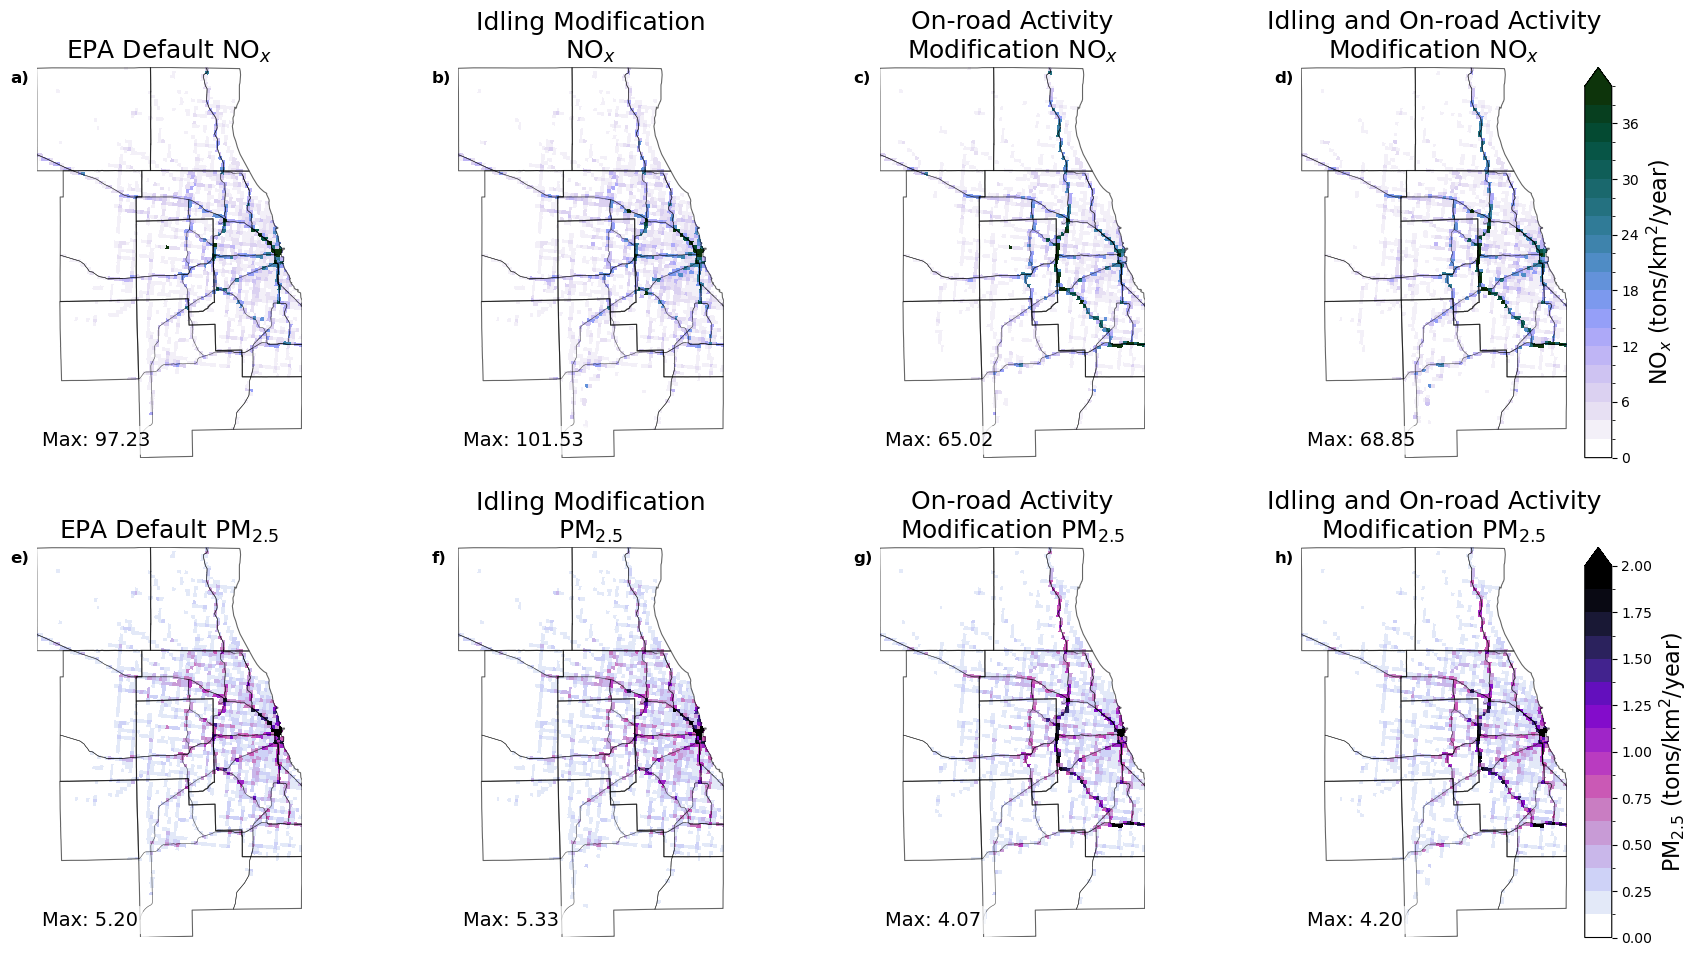

In [22]:
# create 2 x 4 panel figure for annual NOx and PM2.5 emissions across scenarios
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(18, 10), subplot_kw={"projection": ccrs.PlateCarree()})

# NOx across baseline and each activity modification
_panel(axs[0,0], onroad_total_base_cmap, "NOX_peryear", cmap_abs_nox, norm_abs_nox, NOX_VMIN, NOX_VMAX, "EPA Default NO$_x$", ann="max", label="a)")
_panel(axs[0,1], onroad_total_LOCUSIdling_cmap, "NOX_peryear", cmap_abs_nox, norm_abs_nox, NOX_VMIN, NOX_VMAX, "Idling Modification\nNO$_x$", ann="max", label="b)")
_panel(axs[0,2], onroad_total_HDVSpatial_cmap, "NOX_peryear", cmap_abs_nox, norm_abs_nox, NOX_VMIN, NOX_VMAX, "On-road Activity\nModification NO$_x$", ann="max", label="c)")
_panel(axs[0,3], onroad_total_LOCUSIdlingHDVSpatial_cmap, "NOX_peryear", cmap_abs_nox, norm_abs_nox, NOX_VMIN, NOX_VMAX, "Idling and On-road Activity\nModification NO$_x$", ann="max", label="d)")

# PM2.5 across baseline and each activity modification
_panel(axs[1,0], onroad_total_base_cmap, "PM25_peryear", cmap_abs_pm, norm_abs_pm, PM25_VMIN, PM25_VMAX, "EPA Default PM$_{2.5}$", ann="max", label="e)")
_panel(axs[1,1], onroad_total_LOCUSIdling_cmap, "PM25_peryear", cmap_abs_pm, norm_abs_pm, PM25_VMIN, PM25_VMAX, "Idling Modification\nPM$_{2.5}$", ann="max", label="f)")
_panel(axs[1,2], onroad_total_HDVSpatial_cmap, "PM25_peryear", cmap_abs_pm, norm_abs_pm, PM25_VMIN, PM25_VMAX, "On-road Activity\nModification PM$_{2.5}$", ann="max", label="g)")
_panel(axs[1,3], onroad_total_LOCUSIdlingHDVSpatial_cmap, "PM25_peryear", cmap_abs_pm, norm_abs_pm, PM25_VMIN, PM25_VMAX, "Idling and On-road Activity\nModification PM$_{2.5}$", ann="max", label="h)")

# tighten spacing while leaving room on the right for one colorbar per row
fig.subplots_adjust(left=0.01, right=0.94, bottom=0.05, top=0.92, wspace=0.03, hspace=0.23)

# place NOx and PM2.5 colorbars beside their respective rows
pos_top = axs[0,3].get_position()
pos_bot = axs[1,3].get_position()
cax_nox = fig.add_axes([pos_top.x1 + 0.010, pos_top.y0, 0.015, pos_top.height])
cax_pm = fig.add_axes([pos_bot.x1 + 0.010, pos_bot.y0, 0.015, pos_bot.height])

# use the same discrete normalization and colormap as the mapped panels
cb_nox = fig.colorbar(plt.cm.ScalarMappable(norm=norm_abs_nox, cmap=cmap_abs_nox), cax=cax_nox, extend="max")
cb_nox.set_label("NO$_x$ (tons/km$^2$/year)", fontsize=16)

cb_pm = fig.colorbar(plt.cm.ScalarMappable(norm=norm_abs_pm, cmap=cmap_abs_pm), cax=cax_pm, extend="max")
cb_pm.set_label("PM$_{2.5}$ (tons/km$^2$/year)", fontsize=16)

# save publication-quality figure
plt.savefig("Fig_OriginalEmissionComparisons.pdf", dpi=300, bbox_inches="tight")
plt.show()

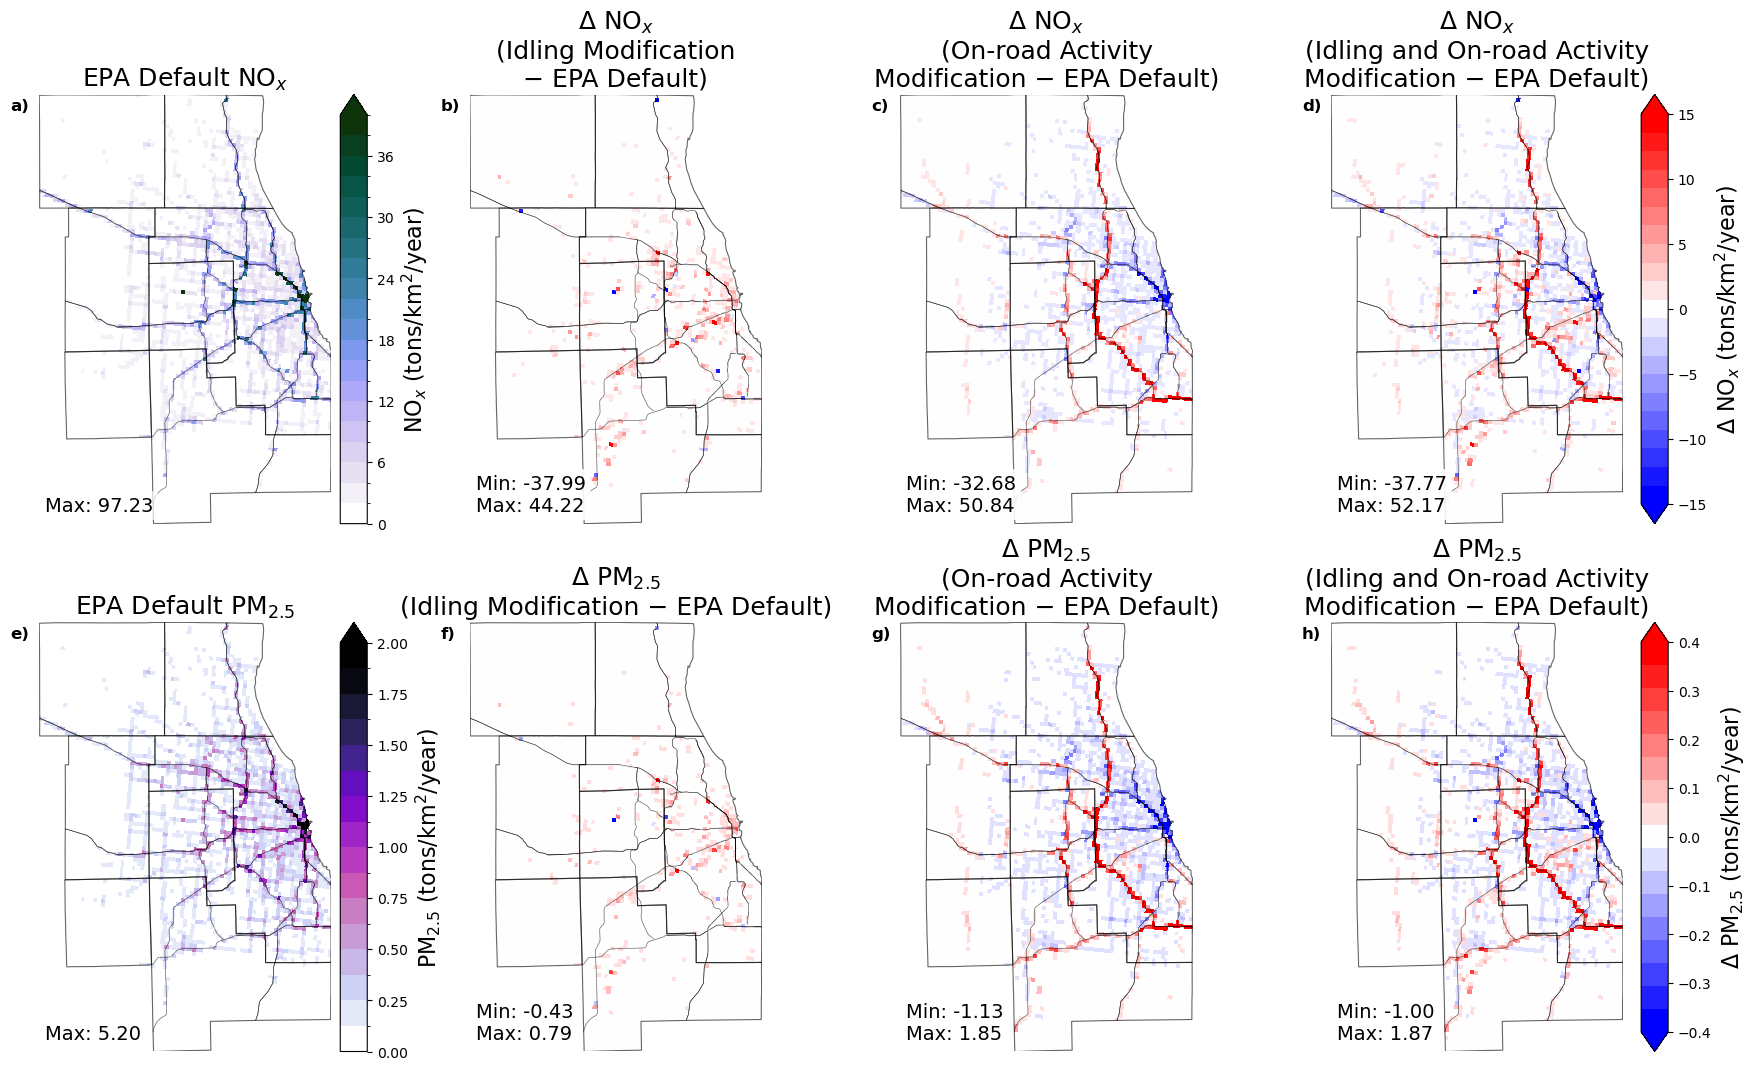

In [26]:
# 2 x 4 panel figure comparing EPA Default emissions with changes from each activity modification
fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(18, 11), subplot_kw={"projection": ccrs.PlateCarree()})

# NOx: EPA Default emissions followed by the change from baseline for each activity modification
_panel(axs[0,0], onroad_total_base_cmap, "NOX_peryear", cmap_abs_nox, norm_abs_nox, NOX_VMIN, NOX_VMAX, "EPA Default NO$_x$", ann="max", label="a)")
_panel(axs[0,1], onroad_total_LOCUSIdling_cmap, "diff_nox", cmap_diff_nox, norm_diff_nox, NOX_DIFF_MIN, NOX_DIFF_MAX, "Δ NO$_x$\n(Idling Modification\n− EPA Default)", label="b)")
_panel(axs[0,2], onroad_total_HDVSpatial_cmap, "diff_nox", cmap_diff_nox, norm_diff_nox, NOX_DIFF_MIN, NOX_DIFF_MAX, "Δ NO$_x$\n(On-road Activity\nModification − EPA Default)", label="c)")
_panel(axs[0,3], onroad_total_LOCUSIdlingHDVSpatial_cmap, "diff_nox", cmap_diff_nox, norm_diff_nox, NOX_DIFF_MIN, NOX_DIFF_MAX, "Δ NO$_x$\n(Idling and On-road Activity\nModification − EPA Default)", label="d)")

# PM2.5: EPA Default emissions followed by the change from baseline for each activity modification
_panel(axs[1,0], onroad_total_base_cmap, "PM25_peryear", cmap_abs_pm, norm_abs_pm, PM25_VMIN, PM25_VMAX, "EPA Default PM$_{2.5}$", ann="max", label="e)")
_panel(axs[1,1], onroad_total_LOCUSIdling_cmap, "diff_pm25", cmap_diff_pm, norm_diff_pm, PM25_DIFF_MIN, PM25_DIFF_MAX, "Δ PM$_{2.5}$\n(Idling Modification − EPA Default)", label="f)")
_panel(axs[1,2], onroad_total_HDVSpatial_cmap, "diff_pm25", cmap_diff_pm, norm_diff_pm, PM25_DIFF_MIN, PM25_DIFF_MAX, "Δ PM$_{2.5}$\n(On-road Activity\nModification − EPA Default)", label="g)")
_panel(axs[1,3], onroad_total_LOCUSIdlingHDVSpatial_cmap, "diff_pm25", cmap_diff_pm, norm_diff_pm, PM25_DIFF_MIN, PM25_DIFF_MAX, "Δ PM$_{2.5}$\n(Idling and On-road Activity\nModification − EPA Default)", label="h)")

# tighten spacing 
fig.subplots_adjust(left=0.01, right=0.96, bottom=0.05, top=0.92, wspace=0.03, hspace=0.23)

# use the first and last columns to position colorbars beside the absolute and difference panels
pos_col1_top = axs[0,0].get_position()
pos_col1_bot = axs[1,0].get_position()
pos_col4_top = axs[0,3].get_position()
pos_col4_bot = axs[1,3].get_position()

# absolute colorbars sit immediately to the right of the EPA Default panels
cax_abs_nox = fig.add_axes([pos_col1_top.x1 + 0.005, pos_col1_top.y0, 0.015, pos_col1_top.height])
cax_abs_pm = fig.add_axes([pos_col1_bot.x1 + 0.005, pos_col1_bot.y0, 0.015, pos_col1_bot.height])

# difference colorbars sit to the right of the final scenario panels
cax_diff_nox = fig.add_axes([pos_col4_top.x1 + 0.010, pos_col4_top.y0, 0.015, pos_col4_top.height])
cax_diff_pm = fig.add_axes([pos_col4_bot.x1 + 0.010, pos_col4_bot.y0, 0.015, pos_col4_bot.height])

# add separate colorbars for absolute NOx and changes in NOx
cb1 = fig.colorbar(plt.cm.ScalarMappable(norm=norm_abs_nox, cmap=cmap_abs_nox), cax=cax_abs_nox, extend="max")
cb1.set_label("NO$_x$ (tons/km$^2$/year)", fontsize=16)
cb1d = fig.colorbar(plt.cm.ScalarMappable(norm=norm_diff_nox, cmap=cmap_diff_nox), cax=cax_diff_nox, extend="both")
cb1d.set_label("Δ NO$_x$ (tons/km$^2$/year)", fontsize=16)

# add separate colorbars for absolute PM2.5 and changes in PM2.5
cb2 = fig.colorbar(plt.cm.ScalarMappable(norm=norm_abs_pm, cmap=cmap_abs_pm), cax=cax_abs_pm, extend="max")
cb2.set_label("PM$_{2.5}$ (tons/km$^2$/year)", fontsize=16)
cb2d = fig.colorbar(plt.cm.ScalarMappable(norm=norm_diff_pm, cmap=cmap_diff_pm), cax=cax_diff_pm, extend="both")
cb2d.set_label("Δ PM$_{2.5}$ (tons/km$^2$/year)", fontsize=16)

# save figure
plt.savefig("Fig3_EmissionComparisons.png", dpi=300, bbox_inches="tight")
plt.savefig("Fig3_EmissionComparisons.pdf", dpi=300, bbox_inches="tight")
plt.show()